# Taller 2 · De 16 canales a la figura

**De la neurona a la figura** · Análisis neuronal en insectos asistido por IA

En el Taller 1 tenían un electrodo y tres neuronas. Aquí tienen **una sonda con 16 electrodos** y dos
registros (experimentos) donde no todo lo que cruza el umbral es una neurona. La pregunta cambia: ya
no es sólo *¿qué neurona responde a qué estímulo?*, sino **¿cuáles de estos grupos son neuronas de
verdad?** y, de ser neuronas de verdad, **¿cuáles responden de manera significativa al estímulo?**

## Cómo está organizado

Trabajan con **dos registros de la misma sonda**:

| archivo | qué trae | para qué |
|---|---|---|
| `taller2_limpia.h5` | 90 s, sin estímulos, unas pocas unidades bien separadas y poco ruido | aprender el método donde todo sale bonito |
| `taller2_ruidosa.h5` | 200 s, tres condiciones de estímulo, muchas más unidades, actividad multiunitaria y artefactos | hacer el trabajo de verdad |

**El pipeline se escribe una sola vez.** Lo construyen sobre la grabación limpia (secciones 1 a 3) y
después lo corren sobre la ruidosa (sección 4 en adelante) cambiando **únicamente el nombre del
archivo**. Por eso todo lo que escriban va en funciones, con argumentos, y no como un guion de arriba
abajo.

**Las secciones 1 a 3** van en las sesiones del 8 y el 10 de septiembre, **4 a 8** en el
laboratorio del 11, y **9 a 12** en la sesión del 15.

## Qué se entrega

Un solo notebook, en el repositorio de la pareja, carpeta `taller2/`, con:

- todas las celdas de código corriendo de arriba abajo sin errores,
- **las 12 preguntas contestadas** (P1 a P12): cada una tiene una parte de
  selección múltiple y una parte abierta,
- **la hoja de respuestas del final llena**, con las letras y los números de su pipeline,
- **OJO:** el `README.md` actualizado (la mayoría no hizo README en el Taller 1),


**Los datos NO van al repositorio.** Entre los dos pesan unos 105 MB. GitHub aceptaría el archivo
grande con una advertencia, así que la razón no es que no quepa: es que **git guarda todas las
versiones de cada archivo para siempre**, y un binario grande infla el repositorio de forma
permanente, aunque después lo borren. Por eso el repositorio lleva el código y el enlace de descarga,
y los datos se bajan cada vez que se abre el notebook. Es la práctica estándar: el código es lo que
cambia y vive en GitHub, y los datos pueden ir o no a un repositorio aparte, como Zenodo.

**Peso: 30 % de la nota del curso.** Habrá además un quiz en clase que puede subir esta nota.

## Cómo se usa la IA aquí

Igual que en el Taller 1. Los iconos:

- ✏️ **Ejercicio**: lo escriben ustedes, con o sin ayuda de la IA.
- ✍️ **Prompt**: además del código, tienen que dejar escrito el prompt que usaron.
- ⚠️ **Trampa**: un error que casi todo el mundo comete la primera vez. Léanlo antes de programar.

Un recordatorio del Taller 1: la IA puede proponer código que corre y da un resultado equivocado.
La única defensa es **graficar el resultado intermedio** y preguntarse si tiene sentido biológico.

## 0 · Preparación

Corran esta celda una sola vez. Baja de una carpeta de Drive los dos registros y el módulo de
verificación. Si les pide reintentar, vuelvan a correrla: los archivos ya bajados no se vuelven a bajar.

⚠️ **Trampa.** La grabación ruidosa son 200 s por 16 canales. En memoria, como números decimales,
son unos 380 MB. Colab lo aguanta, pero **no carguen las dos grabaciones a la vez** si les da error
de memoria: trabajen una, y cuando pasen a la otra reinicien el entorno.

In [1]:
# Carpeta de Drive con los datos y el modulo de verificacion
ID_CARPETA = "1L4t2SJW36ntvtpDvW3wQEUDLRLehXVGv"

import os
if not all(os.path.exists(f) for f in ["taller2_limpia.h5", "taller2_ruidosa.h5",
                                       "verificacion.py"]):
    !pip -q install --upgrade gdown
    import gdown
    gdown.download_folder(id=ID_CARPETA, output=".", quiet=False, use_cookies=False)

for f in sorted(os.listdir(".")):
    if f.endswith((".h5", ".py")):
        print(f, f"{os.path.getsize(f)/1e6:.1f} MB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.0 MB/s eta 0:00:00


Retrieving folder contents


Processing file 1H6kPtLbOGiWSREU4gGVLgKL2HYa6b-rK car1_amplitud.png
Processing file 1UnEgB-Yg9o0cv30BIgf3yHUNaB_yZiWx car2_anchura.png
Processing file 11Qisb4bJBZrj-kqV6ybi_pIQGHR0lQT_ car3_interpolar.png
Processing file 1o3EofLWhdsZnrPUw0inRb5E2lYw7gJS_ car4_centroide.png
Processing file 1KEB5CBNtovTU6O56UkuD3tc5tpfY3HfE car5_caida.png
Processing file 1qZ3_12WdDROAAY7N90YPK1bfqoJOx6nw car6_razon.png
Processing file 1WS82YFlZMwxWyCdZP0Tz-5SQqg8PK6Jr taller2_limpia.h5
Processing file 11PIHZsY2VvL7bk4xbYROu2cmqWkmT5U0 taller2_ruidosa.h5
Processing file 1EfK8kxbX9-t1N-MvUMSACB_aExVlgssa verificacion.py


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1H6kPtLbOGiWSREU4gGVLgKL2HYa6b-rK
To: /content/car1_amplitud.png
100%|██████████| 42.8k/42.8k [00:00<00:00, 23.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1UnEgB-Yg9o0cv30BIgf3yHUNaB_yZiWx
To: /content/car2_anchura.png
100%|██████████| 52.2k/52.2k [00:00<00:00, 14.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=11Qisb4bJBZrj-kqV6ybi_pIQGHR0lQT_
To: /content/car3_interpolar.png
100%|██████████| 38.7k/38.7k [00:00<00:00, 38.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1o3EofLWhdsZnrPUw0inRb5E2lYw7gJS_
To: /content/car4_centroide.png
100%|██████████| 48.0k/48.0k [00:00<00:00, 17.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KEB5CBNtovTU6O56UkuD3tc5tpfY3HfE
To: /content/car5_caida.png
100%|██████████| 54.3k/54.3k [00:00<00:00, 3.42MB/s]
Downloading...
From: https://drive.google.com/

taller2_limpia.h5 31.4 MB
taller2_ruidosa.h5 73.4 MB
verificacion.py 0.0 MB



Download completed


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.signal import butter, sosfiltfilt

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

---
# 1 · El archivo, la sonda y el filtro

Una **sonda lineal** es una aguja plana de silicio con varios sitios de registro (electrodos) repartidos a lo largo de la
punta. Cada sitio mide el voltaje en su vecindad, así que un mismo potencial de acción aparece en
varios sitios a la vez, con amplitud distinta en cada uno.

Esa es una ventaja de tener varios canales, y de ella salen dos cosas que con un electrodo solo
no se pueden hacer:

1. **Ubicar la neurona.** Si la amplitud es máxima en el sitio 6 y va cayendo hacia arriba y hacia
   abajo, la neurona está cerca del sitio 6. Esa posición es una característica más para separar sus
   disparos de los de otras posibles neuronas.
2. **Reconocer lo que no es una neurona.** Una neurona está *localizada*: su señal desaparece a unos
   100 µm. Un artefacto eléctrico aparece **en los 16 sitios a la vez, y puede tener la misma forma
   que un potencial de acción**. Esa diferencia tiene mucho peso a la hora de descartar artefactos.

La amplitud cae con la distancia porque el medio extracelular conduce y dispersa: aproximadamente
como 1/r, donde r es la distancia entre la neurona y el sitio de registro.

El archivo trae el grupo `geometria`, con la posición de cada sitio en micrómetros.

## ¿Qué es un archivo `.h5`?

Un `.h5` (formato **HDF5**, *Hierarchical Data Format*) es el estándar para guardar datos científicos
grandes. Un registro de 200 s en 16 canales a 15 kHz son 48 millones de números: en CSV serían unos
500 MB de texto que hay que leer entero antes de mirar el primer milisegundo. El mismo registro en
`.h5` pesa 73 MB, y permite leer un pedazo sin cargar el resto.

Piensen en un `.h5` como **un sistema de carpetas dentro de un solo archivo**. Tiene tres piezas:

| pieza | analogía | qué es |
|---|---|---|
| **Grupo** (*group*) | carpeta | contiene otros grupos y datasets |
| **Dataset** | archivo | un arreglo de números, como un `np.array` |
| **Atributo** (*attrs*) | etiqueta pegada | metadato corto: frecuencia de muestreo, unidades, notas |

Los atributos son los que explican qué hay dentro del archivo y en qué unidades está.

Tres cosas importantes:

1. **Un dataset no es un arreglo.** `archivo['registro/datos']` no trae nada a memoria hasta que se
   indexa con `[x:y]`. Esa es la ventaja del formato, y también la razón por la que `.shape` responde
   al instante en un archivo de 70 MB.
2. **Los enteros no son microvoltios.** El equipo guarda cuentas del conversor analógico-digital; hay
   que multiplicar por `escala_uV_por_bit`. Si se saltan ese paso, las amplitudes salen unas cinco
   veces más grandes y sin sentido físico.
3. **Los textos salen como bytes** (`b'A'` en vez de `'A'`). Se arregla con `.astype(str)` o
   `.decode()`.

Se abre siempre con `with ... as f:` para que quede cerrado. Un `.h5` abierto dos veces en modo
escritura se corrompe.

### Cómo se abre

Pregúntenle a la IA, o miren el Taller 1. Ese prompt les puede servir como el intercambio 1 del
ejercicio 14b.

## Mirar antes de calcular, y filtrar

La señal cruda mezcla cosas que ocurren a escalas de tiempo muy distintas. Los potenciales de
acción duran alrededor de 1 ms, así que su energía está por encima de unos 300 Hz. Por debajo hay
señales lentas: el potencial de campo local, que es la actividad conjunta de miles de neuronas, la
deriva del electrodo, y el ruido de la red eléctrica a 60 Hz.

Un **filtro pasa-banda de 300 a 5000 Hz** deja pasar los disparos y quita lo demás. El límite de
arriba no es capricho: por encima de 5000 Hz ya casi no hay señal neuronal y sí hay ruido térmico.

⚠️ **Trampa.** Usen `sosfiltfilt` y no `sosfilt`. El primero filtra hacia adelante y hacia atrás, así
que no desplaza la señal en el tiempo. El segundo introduce un retardo que corre todos sus disparos
unos cuantos milisegundos, y eso arruina en silencio todo lo que venga después.

### ✏️ Ejercicio 1

**a)** Abran `taller2_limpia.h5` y averigüen qué contiene: los grupos, los conjuntos de datos, la
frecuencia de muestreo, el factor de conversión a microvoltios y las posiciones de los sitios.

**b)** Dibujen la sonda: un punto por sitio, en su posición real, con el número de canal al lado.

**c)** Carguen la grabación, conviértanla a microvoltios y grafíquenla en dos paneles, cruda y
filtrada, con los 16 canales organizados por profundidad y una ventana de medio segundo.


In [ ]:
# ✏️ Ejercicio 1

**P1.**

**Selección múltiple.** La amplitud cae aproximadamente como 1/r, donde r es la distancia entre la
neurona y el sitio. Una neurona está a 20 µm del sitio más cercano. Moviéndose por la sonda a partir
de ese sitio, ¿a qué distancia la amplitud habrá caído a la mitad?

- **a)** unos 35 µm: menos de lo que hay entre dos sitios vecinos
- **b)** unos 40 µm: exactamente el sitio siguiente
- **c)** unos 80 µm: dos sitios más allá
- **d)** unos 200 µm: cinco sitios más allá

**Abierta.** En la señal filtrada busquen un evento que aparezca **en los 16 canales al mismo
tiempo**. ¿Puede eso ser una neurona? Justifiquen en dos frases usando la caída 1/r.

*Su respuesta:*


---
# 2 · Detectar los disparos en 16 canales

## Repaso: el umbral de detección con la mediana

El umbral se pone en `k` veces el nivel de ruido. Pero hay que medir ese nivel sin que los disparos lo
contaminen: si usan la desviación estándar de la señal, los potenciales de acción la inflan, el umbral
sube y se pierde la capacidad de detectarlos. Mientras más potenciales de acción tenga el registro,
peor.

La solución es medir el ruido con la **mediana del valor absoluto de la señal**. Los disparos ocupan
menos del 1 % del tiempo de grabación, así que la mediana los excluye: describe el ruido mucho mejor
que la desviación estándar, que se calcula a partir de la media y por eso es susceptible a los valores
extremos, que son justamente los que queremos detectar.

Falta un detalle de unidades. Para una campana normal de desviación estándar σ, la mediana del valor
absoluto vale siempre 0,6745 · σ. Dividiendo por esa constante, el número queda expresado como si
fuera una desviación estándar, y entonces **`k = 4` significa que el umbral está 4 desviaciones
estándar del ruido por debajo de cero**. Cero es la media, porque el filtro ya quitó
cualquier componente de deriva lenta.

## Lo nuevo en el Taller 2

**Ahora hay 16 canales.** Un PA cruza el umbral en tres o cuatro sitios a la vez, con unas
décimas de milisegundo de diferencia. Si cuentan cada cruce por separado van a contar el mismo
potencial de acción cuatro veces.

La solución estándar tiene tres pasos:

1. Calcular un umbral **por canal** (cada sitio tiene su propio nivel de ruido).
2. Marcar todos los cruces en cada canal.
3. **Fusionar** los cruces que caen dentro de una misma ventana corta (0,5 ms) en un solo evento, y
   quedarse con el instante y el canal donde el voltaje fue **más negativo de todos**. Ese canal se
   llama el **canal pico** del evento.

### ✍️ Ejercicio 2 · Escriban su prompt

Escriban la función `detectar(X, k=4.5, muerto_ms=0.5, fs=15000)` que reciba la señal filtrada de los
16 canales y devuelva dos arreglos:
1. el instante de cada evento en segundos y
2. su canal pico.

Escríbanle a la IA un prompt que incluya los tres pasos de arriba. Dejen el prompt en la celda de
texto y el código que resultó en la celda de código, con comentarios suyos.

**Su prompt:**

In [ ]:
# ✍️ Ejercicio 2

**P2.**

**Selección múltiple.** Vuelvan a correr la detección sobre la grabación limpia con `muerto_ms = 0.2`
en vez de 0,5. Salen más eventos. ¿De dónde salen?

- **a)** de neuronas más lejanas, que antes no cruzaban el umbral
- **b)** del mismo disparo, contado varias veces
- **c)** del umbral, que se recalcula más bajo
- **d)** del filtro, que deja pasar más ruido

**Abierta.** Digan cuántos eventos detectaron con 0,5 ms y cuántos con 0,2 ms, y expliquen en una
frase por qué 0,5 ms es una elección razonable y 5 ms no lo sería.

*Su respuesta:*


---
# 3 · Dos niveles de medida


Un **evento** es un potencial de acción, no un cruce del umbral. El mismo disparo cruza el
umbral en varios electrodos a la vez, y el detector fusiona esos cruces en uno solo. Para
escoger el canal pico ya tuvo que mirar los 16 canales, pero no guardó nada más.

Por eso la detección de la sección 2 devuelve **dos vectores, uno por evento**: el instante y
el canal pico. Lo primero que hace esta sección es volver a la señal filtrada y recortar una
ventana alrededor de cada instante, en los 16 canales. Ahí aparece la dimensión de canales:

- formas de onda: **eventos × 16 canales × muestras**
- perfil de amplitud, el valor del valle en cada electrodo: **eventos × 16 canales**

De ese perfil salen la amplitud y el centroide.

Todo lo que sigue se mide sobre uno de dos niveles: cada evento, o un grupo ya formado. Las
del segundo nivel no se pueden calcular antes de agrupar, así que no sirven para agrupar. Y
de las del primer nivel, **tres son las que entran a K-means**: son las de la última columna,
y son las que se explican abajo.

| medida | se mide sobre | qué es | ¿agrupa? |
|---|---|---|---|
| instante | cada evento | el momento del valle, en segundos | — |
| canal pico | cada evento | el electrodo donde el voltaje fue más negativo | — |
| perfil de amplitud | cada evento | los 16 valores del valle, uno por electrodo | — |
| **amplitud** | cada evento | el mayor de esos 16 valores | **sí** |
| **media anchura del valle** | cada evento | ancho a media profundidad, en el canal pico | **sí** |
| **centroide de profundidad** | cada evento | promedio de las posiciones, ponderado por el perfil | **sí** |
| número de disparos | un grupo | cuántos eventos quedaron en él | — |
| violaciones del refractario | un grupo | fracción de intervalos menores a 2 ms | — |
| autocorrelograma | un grupo | intervalos entre sus propios disparos | — |
| distribución de amplitudes | un grupo | histograma de la amplitud de sus eventos | — |
| pendiente de caída espacial | un grupo | cómo cae la amplitud al alejarse del canal pico | — |
| razón pico / valle | un grupo | medida sobre la forma de onda promedio del grupo | — |
| correlograma cruzado | dos grupos | intervalos entre los disparos de uno y otro | — |


En esta sección van las tres del primer nivel.


## Tres características de cada PA que van a usar para agruparlos en unidades

**1 · La amplitud.** El valor mínimo del valle en el canal pico, en microvoltios. Depende de dos cosas
a la vez: de qué tan grande sea la neurona y de qué tan cerca esté de la sonda. Recuerden: dos
neuronas distintas pueden llegar con la misma amplitud desde distancias distintas.

Las tres figuras que siguen son **el mismo evento**, medido de tres formas.

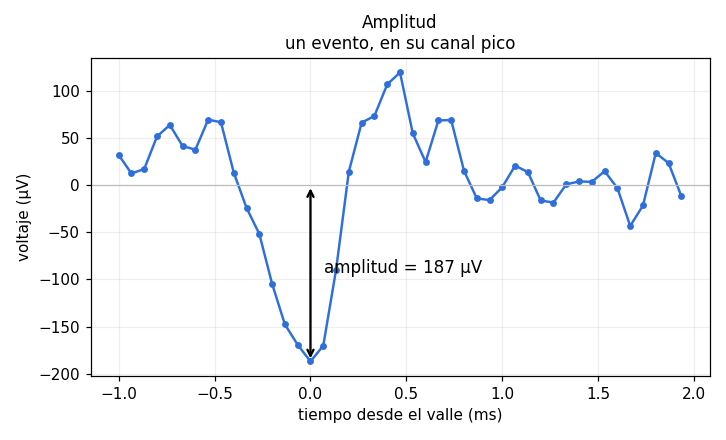

In [3]:
#Corran esta celda.
from IPython.display import Image, display
display(Image("car1_amplitud.png"))

**2 · La media anchura del valle.** El ancho del valle medido a la mitad de su profundidad, en
milisegundos. Distingue neuronas que la amplitud no distingue, porque depende del tipo de célula y no
de la distancia a la que esté.

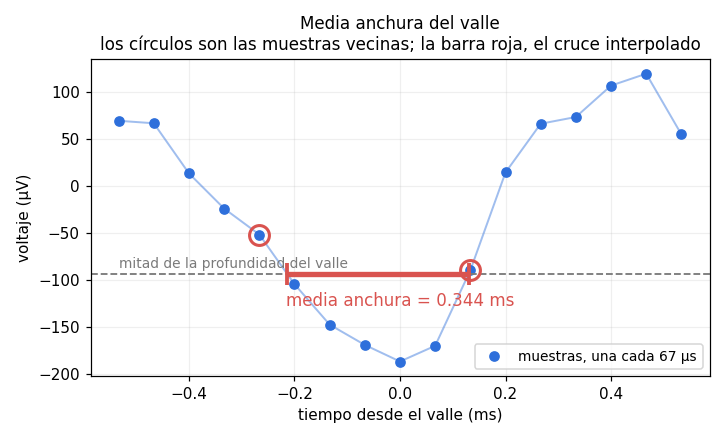

In [4]:
#Corran esta celda.
display(Image("car2_anchura.png"))

⚠️ **Trampa importante.** El potencial de acción completo dura entre 0,6 y 1,4 ms, así que a 15 000
muestras por segundo caben entre 9 y 21 muestras. El problema no es ese. Es que **la media anchura del
valle abarca sólo unas 5 muestras** en las unidades angostas y 9 en las anchas, y si la miden contando
muestras enteras, el resultado sólo puede saltar de 67 en 67 µs. Perderían resolución y no estimarían
la anchura del valle exacta: la nube de mediciones les sale como un peine. Hay que **interpolar
linealmente entre muestras** para encontrar dónde exactamente la señal cruza la mitad de la
profundidad.

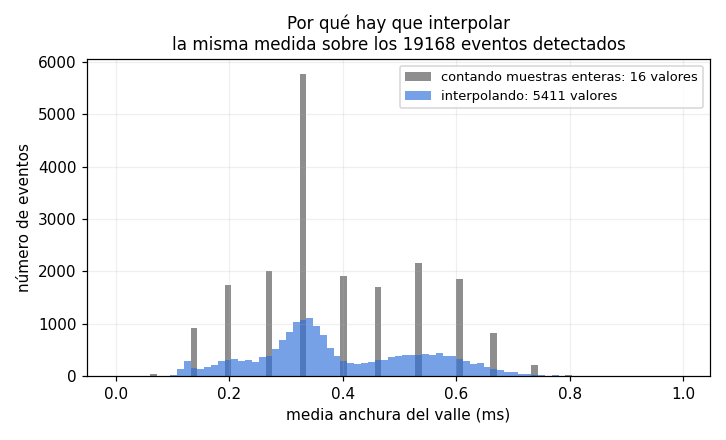

In [5]:
#Corran esta celda.
display(Image("car3_interpolar.png"))

**3 · El centroide de profundidad.** Los sitios de la sonda están en posiciones fijas: el primero a
0 µm de la punta, el segundo a 40, y así hasta 600. Un mismo disparo llega a varios sitios con
amplitudes distintas, y de ahí se estima **a qué profundidad está la neurona que lo produjo**: es el
promedio de las posiciones de los sitios, ponderado por la amplitud que el disparo alcanzó en cada
uno.

El evento de las figuras anteriores llega con 122 µV al sitio de 200 µm, 187 µV al de 240 y 69 µV al
de 280. Su centroide es

(200·122 + 240·187 + 280·69) / (122 + 187 + 69) = **234 µm**

Los otros trece sitios no entran en la cuenta. Sólo se usan aquellos donde la amplitud supera el 30 %
del máximo, que en este evento son 56 µV, porque en los sitios lejanos lo que se mide es ruido y
arrastraría el centroide hacia la mitad de la sonda.

Fíjense en algo: el centroide **se calcula sobre cada disparo, pero lo que estima es una propiedad de
la neurona**, no de ese disparo en particular. Por eso separa tan bien. Cada potencial de acción trae,
en su perfil de amplitudes, una medición ruidosa de dónde está la célula que lo disparó.

In [ ]:
#Corran esta celda
display(Image("car4_centroide.png"))

### ✏️ Ejercicio 3

**a)** Extraigan la forma de onda de cada evento en los 16 canales, desde 1,0 ms antes hasta 2,0 ms
después del instante detectado. El resultado es un arreglo de tres dimensiones: eventos × canales ×
muestras.

**b)** Calculen las tres características para cada evento.

**c)** Grafiquen las tres nubes de puntos posibles con esas tres características, en tres paneles.

In [ ]:
# ✏️ Ejercicio 3

**P3.**

**Selección múltiple.** ¿Cuál de estas medidas **no** se puede calcular sobre un evento aislado?

- **a)** la amplitud
- **b)** la media anchura del valle
- **c)** el centroide de profundidad
- **d)** las violaciones del período refractario

**Abierta.** De los tres paneles de la nube de puntos, ¿cuál separa mejor los grupos, y por qué esa
pareja de características y no otra? Digan si hay un par de grupos que se confunda en un panel y se
separe en otro.

*Su respuesta:*


---
# Segunda parte · La grabación ruidosa

Aquí empieza el trabajo real. A partir de esta sección todo se hace sobre `taller2_ruidosa.h5`.

---
# 4 · La grabación ruidosa, y agrupar con K-means

Si escribieron las funciones bien, la primera parte de esta sección son cuatro líneas: cargar,
filtrar, detectar, extraer características. Nada de copiar y pegar con cambios.

⚠️ **Trampa.** Aquí es donde se paga haber dejado números escritos dentro de una función. El caso más
común es el umbral: si en la sección 2 guardaron el valor en microvoltios que les dio en la grabación
limpia, en vez de recalcular `k · MAD` sobre la señal que reciban, aquí les va a fallar en silencio.
Esta grabación tiene más ruido de fondo, así que su MAD es mayor y el umbral correcto es otro. Con el
umbral viejo, que es más bajo, van a detectar muchísimos cruces que no son disparos.

Lo mismo vale para cualquier otra cosa que hayan fijado mirando la primera grabación: el nombre del
archivo, el número de grupos, o dar por hecho que el archivo no trae protocolo de estímulos. Si les
toca abrir una función y cambiarle algo para que corra aquí, eso es lo que hay que arreglar.

Lo que van a encontrar es que aparecen muchos más eventos y que la nube de puntos ya no son cuatro
manchas limpias. Hay tres razones, y conviene tenerlas claras desde ya:

**Actividad multiunitaria (MUA).** La amplitud cae con la distancia, así que hay muchísimas neuronas
lejanas cuyos disparos llegan a la sonda debilitados. Individualmente son demasiado pequeños para
identificarlos, pero son tantos que en conjunto cruzan el umbral todo el tiempo. Forman una nube sin
fronteras, pegada al umbral por debajo. **La MUA es actividad neuronal de verdad**: son potenciales de
acción, sólo que no se puede decir de cuál neurona vino cada uno.

**Artefactos.** Eventos eléctricos o mecánicos que no son neuronales: el equipo, el movimiento del
animal, el estímulo. Cruzan el umbral y se detectan igual que un disparo.

**Cruces del umbral por ruido térmico.** El ruido de fondo es aleatorio y de vez en cuando, por azar,
baja lo suficiente. No son disparos de nada.

## K-means y el problema de elegir k

**K-means** reparte los puntos en `k` grupos, poniendo cada punto en el grupo cuyo centro le queda más
cerca. Ya lo usaron en el Taller 1. Aquí hay dos cosas nuevas.

**Hay que estandarizar las características antes.** K-means mide distancias, y las tres
características están en unidades que no se pueden comparar: el centroide va de 0 a 600 µm, la
anchura de 0,1 a 0,9 ms y la amplitud de 90 a 300 µV. Si no se corrige, la distancia queda dominada por el
centroide y las otras características no cuentan. La corrección es restarle a cada característica su
media y dividirla por su desviación estándar: exactamente el Z-score que vieron en la sesión de
estadística, usado aquí para otra cosa.

**Elegir k mal tiene dos formas de fallar, y son opuestas.**

- Si `k` es **muy pequeño**, dos neuronas distintas caen en el mismo grupo. Y hay una trampa: la nube
  de MUA es enorme, así que se lleva varios centros y deja pocos para las neuronas de verdad.
- Si `k` es **muy grande**, una sola neurona queda partida en dos grupos.

No hay forma de acertar de una. Lo que se hace en la práctica es pasarse de `k` a propósito y después
**arreglar**: descartar lo que no sirve y unir lo que quedó partido. Las secciones 5, 6 y 7 son
exactamente eso.

### ✏️ Ejercicio 4

**a)** Corran su pipeline completo sobre la grabación ruidosa y grafiquen las mismas tres nubes de la
sección 3.

**b)** Estandaricen sus tres características.

**c)** Corran K-means con al menos tres valores distintos de `k` (por ejemplo 8, 16 y 25) y grafiquen
el resultado de cada uno sobre el panel de centroide contra anchura.

**d)** Elijan un `k` para seguir trabajando.


In [6]:
# ✏️ Ejercicio 4

**P4.**

**Selección múltiple.** En la grabación ruidosa aparece una nube ancha, sin fronteras, pegada al
umbral por debajo. ¿De qué está hecha, sobre todo?

- **a)** de artefactos del equipo
- **b)** de actividad multiunitaria: disparos reales de neuronas demasiado lejanas para identificarlas
- **c)** de cruces del umbral por ruido térmico, y de nada más
- **d)** de una sola neurona cuya amplitud varía mucho

**Abierta.** ¿Qué `k` escogieron y con qué argumento? No vale "porque se ve bien": señalen un grupo
que con el `k` más pequeño se vea como dos cosas pegadas, y uno que con el `k` más grande se vea como
la mitad de otro, y digan en qué se nota cada cosa.

*Su respuesta:*


---
# 5 · Las métricas de calidad

Aquí es donde este taller se separa de lo que hace un programa automático. Ya tienen grupos. La
pregunta es cuáles de esos grupos son una neurona.

Estamos en el **segundo nivel de medida** del que habla la sección 3: todo lo que sigue se calcula
sobre un grupo entero, no sobre un disparo suelto. Varias de estas medidas se sacan de la **forma de
onda promedio** del grupo, que es más limpia que cualquier disparo individual porque el ruido se
cancela al promediar.

Son siete medidas tomadas de **bombcell**, una herramienta publicada que hace control de calidad sobre
datos ya agrupados. Los umbrales son los suyos, ajustados a esta sonda.

| medida | qué es | umbral | qué decide |
|---|---|---|---|
| número de picos y valles | Un potencial de acción tiene un valle y a lo sumo dos picos. Si la forma promedio oscila, no es una neurona. | picos ≤ 2 y valles ≤ 2 | ¿es de origen neuronal? |
| duración de la onda | Tiempo del valle al pico de repolarización. | entre 100 y 1150 µs | ¿es de origen neuronal? |
| pendiente de caída espacial | Ajuste de la amplitud contra la distancia al canal pico, en amplitud normalizada por µm. Una neurona se apaga con la distancia; un artefacto llega casi igual a toda la sonda. | más negativa que −0,004 | ¿es de origen neuronal? |
| razón pico / valle | Altura del pico positivo más grande dividida por la profundidad del valle. | por encima de 0,8 es **no somática** | ¿qué parte de la neurona se registró? |
| violaciones del refractario | Fracción de intervalos entre disparos menores a 2 ms. Una neurona no puede dispararse dos veces tan seguido, así que si los hay es porque hay más de una en el grupo. | menos de 1,5 % | ¿una neurona o varias? |
| disparos faltantes | Se ajusta una campana a la distribución de amplitudes. Si el umbral de detección cortó la cola baja, el grupo está incompleto. | menos de 20 % | ¿una neurona o varias? |
| número de disparos | Con muy pocos disparos ninguna de las otras medidas es confiable. | al menos 300 | ¿una neurona o varias? |

Dos notas sobre los umbrales de esta tabla:

**Los valles.** Bombcell exige uno solo; aquí se admiten dos, porque el filtro pasa-banda le agrega un
rizado a las ondas predominantemente positivas y si no las marcaría como ruido.

**La pendiente.** En esta sonda los sitios están cada 40 µm, así que dentro de los 100 µm del ajuste
caben apenas tres. Con tan pocos puntos el criterio es débil: en este registro el artefacto da −0,0042
y la actividad multiunitaria −0,0058, mientras que las unidades bien aisladas dan entre −0,0077 y
−0,0090. **La pendiente sola no alcanza a separar el artefacto**, y quien lo atrapa es el número de
picos. Si suben el umbral para atrapar el artefacto, empiezan a marcar como ruido actividad
multiunitaria que sí es neuronal.

**Por qué la razón pico / valle sube cuando no se registra la zona de disparo.** El electrodo
extracelular no mide el voltaje de la membrana: mide **las corrientes que entran y salen de ella**.
Donde la corriente entra, que es el punto activo por donde pasa el sodio, el exterior se vuelve
negativo, y ese es el valle. Esa corriente tiene que salir por otro lado de la célula, y donde sale el
exterior se vuelve positivo: esos son los picos.

Si el electrodo está junto a la zona donde nace el disparo, domina la corriente que entra: valle
profundo y picos pequeños. Si está sobre un axón por el que el disparo va pasando, ve la onda llegar y
alejarse, y delante y detrás del punto activo la corriente está saliendo, así que los picos crecen
hasta igualar o superar al valle. Junto a una dendrita pasa algo parecido, porque lo que llega ahí es
sobre todo corriente de retorno.

No es que la neurona sea distinta: es que el electrodo está en otra parte de ella. Bombcell llama
**no somáticas** a esas unidades. Son señal neuronal legítima, pero su centroide de profundidad no
dice dónde está el cuerpo de la célula, porque un axón puede venir de lejos.

### Las dos figuras de esta sección

La caída espacial y la razón pico/valle son las dos que menos se entienden por escrito. Así se ven
sobre este mismo registro.

In [ ]:
from IPython.display import Image, display
for f in ["car5_caida.png", "car6_razon.png"]:
    display(Image(f))

### ✍️ Ejercicio 5 · Escriban su prompt

Calculen las siete medidas para cada uno de sus grupos y armen una tabla, una fila por grupo.

⚠️ **Trampa: alinear antes de promediar.** Dentro de un grupo no todos los eventos tienen el pico en
el mismo sitio. Si promedian los 16 canales tal cual, están sumando perfiles corridos unos respecto a
otros, y la suma sale aplanada: el grupo parece no decaer con la distancia y lo van a marcar como
ruido, aunque cada evento por separado decaiga bien.

Hay que medir la caída **respecto al canal pico de cada evento**:

1. Para cada evento, tomen la amplitud del valle en los 16 sitios y divídanla por su máximo.
2. Anoten cada uno de esos valores junto con su distancia al canal pico **de ese evento**.
3. Junten los pares de todos los eventos y ajusten una recta, usando sólo las distancias de 100 µm
   o menos.

**Disparos faltantes.** Los disparos de una misma neurona no llegan todos con la misma amplitud:
varían alrededor de un valor típico, así que su histograma tiene forma de campana. Si la neurona es
pequeña o está lejos, **la parte baja de esa campana cae por debajo del umbral de detección**. Esos
disparos ocurrieron, pero nunca se detectaron: están faltando en el grupo, y por eso la tasa de
disparo que midan va a ser menor que la real.

Para estimar cuántos faltan:

1. Hagan el histograma de amplitudes del grupo.
2. Ajusten una campana usando **sólo la mitad que queda por encima del pico del histograma**, que es
   la parte que el umbral no alcanzó a cortar.
3. Calculen qué fracción de esa campana ajustada queda por debajo del umbral. Esa es la estimación de
   lo que falta.

Si el ajuste no converge, eso ya es una respuesta: la distribución no tiene forma de campana, así que
el grupo no es una sola neurona.

**Su prompt:**

In [ ]:
# ✍️ Ejercicio 5

**P5.**

**Selección múltiple.** Un grupo tiene la pendiente de caída espacial casi plana: su forma de onda
llega con amplitud parecida a los 16 sitios. Lo más probable es que sea

- **a)** una neurona muy grande
- **b)** una neurona muy pegada a la sonda
- **c)** un artefacto, porque una neurona se apaga con la distancia
- **d)** una unidad no somática

**Abierta.** ¿Cuáles de sus grupos tienen la distribución de amplitudes cortada por el umbral?
Grafiquen el histograma de uno de ellos junto al de un grupo sano, y digan qué implica esa diferencia
para el porcentaje de disparos faltantes y para la tasa de disparo que van a reportar después.

*Su respuesta:*


---
# 6 · Autocorrelograma y correlograma cruzado

Estas dos figuras contestan preguntas que ninguna de las medidas anteriores contesta.

El **autocorrelograma** de un grupo es el histograma de todos los intervalos de tiempo entre sus
propios disparos. Si el grupo es una sola neurona, tiene que haber un **hueco** alrededor de cero: el
período refractario. Si no hay hueco, hay más de una neurona adentro.

⚠️ **Ojo con dónde miran.** Su detector fusiona en un solo evento todos los cruces que caen dentro de
0,5 ms, así que **por construcción no puede haber dos detecciones separadas por menos de eso**. El
centro del correlograma está vacío para todos los grupos, tengan o no una sola neurona: ese vacío lo
puso el detector, no la biología. Lo que hay que mirar es **la banda entre 0,5 y 2 ms**, que es la
parte del período refractario que el detector no tocó. Ahí sí, vacía significa una sola neurona.

El **correlograma cruzado** entre dos grupos es lo mismo pero entre grupos distintos: para cada
disparo del grupo A, cuántos disparos del grupo B cayeron a cada distancia de tiempo. Y aquí está el
argumento bonito del taller:

> Si dos grupos son dos neuronas distintas, no tienen por qué respetar el refractario del otro, y la
> banda de 0,5 a 2 ms se ve tan poblada como el resto. **Si esa banda está vacía, los dos grupos son
> la misma neurona partida en dos.**

Ese vacío es la prueba de sobre-división, y es la razón por la que uno puede pasarse de `k` sin miedo:
lo que se partió de más se detecta y se vuelve a unir.

⚠️ **Trampa de escala.** El período refractario dura unos 2 ms. Si grafican de −50 a +50 ms con barras
de 1 ms, esa banda son dos barras de cien y no se ve nada. **Grafiquen de −20 a +20 ms con barras de
0,25 ms.**

⚠️ **Y una advertencia que les va a pasar.** La prueba tiene un falso positivo conocido. Si dos
neuronas **distintas** están muy juntas en la sonda, sus disparos casi simultáneos caen dentro de la
misma ventana muerta y el detector los cuenta como uno solo, así que la banda también sale vacía. Lo
que separa los dos casos es la **forma de onda promedio**: si los dos grupos son la misma neurona,
sus formas promedio son iguales; si son dos neuronas vecinas, no lo son. Comparen las formas antes de
fusionar nada.

### ✏️ Ejercicio 6

**a)** Escriban las funciones del autocorrelograma y del correlograma cruzado, de −20 a +20 ms con
barras de 0,25 ms. Para comparar grupos entre sí les va a servir un número, no sólo la figura: por
ejemplo el promedio de las barras entre 0,5 y 2 ms dividido por el promedio de las barras entre 5 y
20 ms. Si es cercano a cero, la banda está vacía.

**b)** Grafiquen el autocorrelograma de todos sus grupos.

**c)** Calculen el correlograma cruzado de las parejas de grupos que estén cerca en la nube de
características, que son las candidatas a ser una sola neurona.

In [ ]:
# ✏️ Ejercicio 6

**P6.**

**Selección múltiple.** Dos grupos tienen el correlograma cruzado con la banda de 0,5 a 2 ms vacía.
Lo primero que hay que sospechar es que

- **a)** son dos neuronas vecinas distintas
- **b)** son la misma neurona, partida en dos grupos
- **c)** están conectadas por una sinapsis
- **d)** los dos son artefactos

**Abierta.** Busquen una pareja así en sus datos. Muestren la figura, comparen las dos formas de onda
promedio y decidan si las fusionan o no. Justifiquen la decisión: la banda vacía sola no alcanza.

*Su respuesta:*


---
# 7 · Curar: ponerle una etiqueta a cada grupo

Ahora júntenlo todo. Cada grupo recibe **una** de estas cuatro etiquetas.

**`noise`.** No es actividad neuronal. Se reconoce porque la forma de onda no parece un potencial de
acción (demasiados picos, duración fuera de rango) o porque **no cae con la distancia**: aparece con
la misma amplitud en toda la sonda. Se descarta y no se vuelve a mirar.

**`non-somatic`.** Es actividad neuronal, pero la onda es predominantemente positiva, lo que indica
que se está registrando un axón o una dendrita y no la zona donde nace el potencial de acción. Se
puede analizar, pero hay que decir en la figura que es no somática.

**`mua`.** Son potenciales de acción de verdad, pero de más de una neurona, o de una neurona a la que
le faltan disparos. Se reconoce por las violaciones del refractario, por la distribución de amplitudes
cortada por el umbral, o por tener muy pocos disparos. **La MUA sirve para medir actividad de la
población, pero no sirve para decir "esta neurona responde a este estímulo".**

**`good`.** Pasa todo. Es una neurona, aislada, completa.

Sobre el vocabulario, una precisión que importa en insectos: **no se debe hablar de "unidades
somáticas"**. Las neuronas de insecto son en su mayoría unipolares, con el soma en la corteza celular
de la periferia, fuera del neuropilo, y ese soma normalmente no genera el potencial de acción
propagado: la zona donde nace el disparo está en el neurito, ya dentro del neuropilo. Por eso la
distinción de bombcell es sobre la **forma de la onda registrada**, no sobre qué parte anatómica se
supone que uno está tocando.

### ✏️ Ejercicio 7

**a)** Apliquen las fusiones que decidieron en la sección 6.

**b)** Asignen una de las cuatro etiquetas a cada grupo resultante.

**c)** Hagan una figura resumen: para cada grupo etiquetado `good` o `non-somatic`, su forma de onda
promedio en los 16 sitios y su autocorrelograma.

In [ ]:
# ✏️ Ejercicio 7

**P7.**

**Selección múltiple.** Un grupo tiene la forma de onda promedio con el pico positivo casi tan grande
como el valle (razón pico/valle por encima de 0,8), y todo lo demás en orden. Su etiqueta es

- **a)** `good`
- **b)** `mua`
- **c)** `noise`
- **d)** `nonsomatic`

**Abierta.** Escojan **tres** de sus grupos, uno de cada etiqueta distinta, y justifiquen cada
etiqueta nombrando las medidas concretas que la decidieron y sus valores. Una o dos frases por grupo.

*Su respuesta:*


---
# 8 · Verificación contra la verdad oculta

Los datos son sintéticos, así que existe la respuesta. El módulo `verificacion.py` la tiene guardada y
la compara con la suya sin mostrársela.

```python
import verificacion as v
v.usar("taller2_ruidosa.h5")
v.verificar_deteccion(tiempos)              # precisión, exhaustividad, F1
v.verificar_canal_pico(tiempos, canales)    # ¿acertaron dónde está cada neurona?
v.verificar_unidades(tiempos, grupos)       # matriz de confusión
v.verificar_curacion(tiempos, grupos, etiquetas)   # ¿acertaron las etiquetas?
```

Los nombres de arriba son los de este ejemplo, no una exigencia: pásenle lo que hayan calculado
ustedes. `tiempos` son los instantes de sus detecciones en segundos, `canales` el canal pico de cada
una, `grupos` el número de grupo que les asignó K-means, y `etiquetas` un diccionario que le asigna a
cada número de grupo una de las cuatro palabras: `{0: "good", 1: "mua", ...}`.

Presten atención a la última línea que imprime `verificar_deteccion`: **qué fracción de lo que
conservaron viene de una neurona que se puede identificar una por una.** Antes de curar, buena parte
de sus detecciones son actividad multiunitaria y artefactos, así que ese número es bajo aunque su
detector sea perfecto. Es la medida de para qué sirvió curar, y es el resultado central de la primera
mitad del taller.

La exhaustividad, por su parte, se mide sólo sobre las unidades bien aisladas. Los disparos de las
neuronas lejanas llegan casi todos por debajo del umbral: no son detectables, y contarlos como fallas
no diría nada sobre su detector.

### ✏️ Ejercicio 8

**a)** Corran las cuatro verificaciones.

**b)** Vuelvan a correr `verificar_deteccion`, pero pasándole **sólo** los disparos de los grupos que
ustedes NO etiquetaron como `noise` ni como `mua`. Es decir, lo que de verdad se llevarían al
análisis de la tercera parte.

In [ ]:
# ✏️ Ejercicio 8

**P8.**

**Selección múltiple.** La fracción "de una unidad identificable" sube cuando vuelven a correr
`verificar_deteccion` sólo con los grupos que no marcaron `mua` ni `noise`. Sube porque

- **a)** se detectan más disparos que antes
- **b)** sale del conteo lo que no viene de una neurona identificable una por una
- **c)** mejora la precisión de la detección
- **d)** el umbral se recalcula sobre menos datos

**Abierta.** Digan cuánto subió esa fracción y cuántas unidades `good` recuperaron de las que había.
Miren la matriz de confusión y digan qué les pasó a las que no recuperaron: ¿las fusionaron, las
partieron o las descartaron?

*Su respuesta:*


---
# Tercera parte · Del tren de disparos a la figura

De aquí en adelante trabajan **sólo con los grupos etiquetados `good`**. Los `non-somatic` los pueden
incluir si los marcan como tales en la figura. Los `mua` y los `noise` quedan fuera.

---
# 9 · Raster y PSTH

El registro trae el grupo `estimulos`, con el instante de inicio de cada ensayo y su condición (A, B o
C). Cada ensayo dura 3 s: 1 s antes del estímulo, 0,5 s de estímulo y 1,5 s después.

El **raster** es la figura más honesta que existe para datos de disparos: un punto por cada potencial
de acción, una fila por ensayo. No promedia nada, así que muestra la variabilidad tal cual es.

El **PSTH** (histograma peri-estímulo) es el raster promediado: se cuentan los disparos en ventanas de
tiempo y se divide por el número de ensayos y por el ancho de la ventana, para obtener una tasa en
hertz. El ancho de la ventana es una decisión suya: muy angosta y la curva es puro ruido, muy ancha y
se pierde el momento en que la respuesta empieza.

### ✏️ Ejercicio 9

**a)** Escriban la función que convierte tiempos absolutos a tiempos relativos al inicio del estímulo
de cada ensayo.

**b)** Hagan el raster de cada unidad `good`, con las tres condiciones separadas por color o por panel,
y la ventana del estímulo marcada.

**c)** Hagan el PSTH de cada unidad y cada condición.

In [ ]:
# ✏️ Ejercicio 9

**P9.**

**Selección múltiple.** Si el ancho de la ventana del PSTH es demasiado grande, lo que ocurre es que

- **a)** el PSTH se llena de picos espurios
- **b)** se pierde la resolución temporal: una respuesta corta queda diluida en la ventana
- **c)** cambia el número total de disparos
- **d)** el raster cambia también

**Abierta.** Mirando **sólo el raster**, antes de calcular nada: ¿cuáles unidades responden al
estímulo y a cuáles condiciones? Hagan la lista. Después digan qué ancho de ventana escogieron para
el PSTH y qué se pierde con los otros dos que probaron.

*Su respuesta:*


---
# 10 · ¿La respuesta es real? Z-score, t-test y bootstrap

Tres herramientas, y cada una contesta una pregunta distinta. Esto es lo que vieron en las sesiones de
estadística, aplicado a sus propios datos.

**El Z-score responde: ¿cuánto se salió esta unidad de lo que hace normalmente?** Se toma la actividad
basal de la unidad (el segundo anterior al estímulo, en todos los ensayos), se calculan su media y su
desviación estándar, y la respuesta se expresa en cuántas desviaciones estándar por encima de esa
basal quedó. Sirve para **comparar unidades entre sí**, y en este registro hay un caso que lo muestra
bien: dos de las unidades llegan casi a la misma tasa durante el estímulo, unos 41 Hz las dos, pero
una parte de una basal de 4,9 Hz y la otra de 10,6 Hz. En hertz crudos son indistinguibles; en
Z-score, una queda muy por encima de la otra. Ustedes van a encontrar ese par en el ejercicio 12.

**El t-test responde: ¿esta diferencia se explica por el azar?** Compara la tasa durante el estímulo
contra la basal, ensayo por ensayo (pareado), o compara dos condiciones entre sí. Da un valor p, que
es la probabilidad de observar una diferencia al menos tan grande como la que vieron si en realidad no
hubiera ninguna diferencia.

**El bootstrap responde: ¿qué tan precisa es mi medición?** En vez de suponer que los datos siguen una
campana, se remuestrean los ensayos con reemplazo miles de veces, se calcula la media de cada
remuestreo, y se toma el rango que contiene el 95 % central de esas medias. Ese es el intervalo de
confianza. Funciona aunque los datos no sean normales, que es el caso habitual con tasas de disparo.

⚠️ **Trampa conceptual, y es la más importante del taller.** Tienen 20 ensayos por condición, pero esos
20 ensayos son de **la misma neurona en el mismo animal**. No son 20 observaciones independientes de
"cómo responden las neuronas a este estímulo": son 20 observaciones de una sola neurona. Tratarlas
como si fueran independientes para hablar de la población se llama **pseudorreplicación** y es uno de
los errores más comunes en la literatura. Sus conclusiones estadísticas valen **para cada unidad por
separado**, no para "las neuronas de esta estructura".

### ✏️ Ejercicio 10

Para cada unidad `good` y cada condición:

**a)** La tasa basal y la tasa durante el estímulo, ensayo por ensayo.

**b)** El Z-score de la respuesta respecto a la basal de esa unidad.

**c)** Un t-test pareado, basal contra estímulo.

**d)** El intervalo de confianza del 95 % de la tasa evocada, por bootstrap con al menos 5000
remuestreos.

Armen una tabla con todo.

In [ ]:
# ✏️ Ejercicio 10

**P10.**

**Selección múltiple.** Una unidad tiene la tasa evocada más alta en hertz, pero no el Z-score más
alto. La explicación es que

- **a)** tiene menos ensayos que las demás
- **b)** su actividad basal es más variable, y el Z-score divide por esa variabilidad
- **c)** el t-test no se le puede aplicar
- **d)** su respuesta empieza más tarde

**Abierta.** Elijan una unidad cuyo t-test dé un p pequeño y otra que dé un p grande, y expliquen la
diferencia mirando la **variabilidad entre ensayos**, no sólo las medias. ¿Algún intervalo de
confianza por bootstrap incluye la tasa basal? ¿Qué concluyen de esa unidad?

*Su respuesta:*


---
# 11 · La figura final

Una figura de resultados de cuatro paneles, con todas las unidades `good` juntas. Esta sección se
califica panel por panel.

**Panel A.** La sonda con las unidades ubicadas en su centroide de profundidad, y al lado la forma de
onda promedio de cada una. Es la figura que dice "esto fue lo que registramos".

**Panel B.** El raster de una sola unidad, con las tres condiciones. Escojan una que responda a una
condición y no a las otras, que es la que hace visible el contraste.

**Panel C.** **El PSTH general por estímulo**: todas las unidades `good` promediadas, una curva por
condición, con su banda de confianza.

**Panel D.** **El swarmplot por estímulo**: un punto por ensayo, agrupados por condición, con la media
y su intervalo de confianza encima. Un swarmplot muestra todos los datos, que es lo que un diagrama de
barras esconde.

**Reglas de figura científica, y aquí sí se evalúan una por una:**

1. Todos los ejes rotulados, con unidades.
2. Escalas de tiempo iguales entre paneles que se comparan.
3. Nada de rojo y verde como única distinción entre categorías.
4. La ventana del estímulo marcada de la misma forma en todos los paneles.
5. Cada panel legible sin leer el texto: si hay que explicarlo, falta un rótulo.
6. Pie de figura que diga qué se muestra, cuántos ensayos y qué representan las barras de error.

### ✏️ Ejercicio 11

In [ ]:
# ✏️ Ejercicio 11

**P11.**

**Selección múltiple.** El PSTH general del panel C promedia unidades que responden a cosas
distintas. Lo que ese promedio esconde es

- **a)** el número total de disparos
- **b)** la selectividad de cada unidad: mezcla respuestas a condiciones distintas en una sola curva
- **c)** la latencia de la respuesta
- **d)** la tasa basal

**Abierta.** Escriban el pie de la figura completo, como iría en un artículo: qué hay en cada panel,
cuántas unidades, cuántos ensayos, qué son las barras de error.

*Su respuesta:*


---
# 12 · Conclusión y conversación con la IA

### ✏️ Ejercicio 12a · El párrafo de resultados

Escriban un párrafo de resultados, como iría en un artículo. Máximo 200 palabras. Tiene que decir:
cuántas unidades registraron y cuántas sobrevivieron a la curación, qué criterios usaron para
descartar las demás, qué unidades respondieron a qué condiciones, y con qué evidencia estadística.

Nada de "se observó que" ni "los datos sugieren". Números.

**Resultados:**

### ✏️ Ejercicio 12b · Tres intercambios con la IA

Documenten tres momentos en que la IA les dio algo equivocado y ustedes lo corrigieron. Para cada uno:
el prompt, la respuesta del modelo, qué estaba mal y cómo lo arreglaron.

Vale más un error entendido que tres respuestas correctas.

**Intercambio 1**

*Prompt:*

*Respuesta del modelo:*

*Qué estaba mal:*

*Cómo lo corregimos:*

**Intercambio 2**

*Prompt:*

*Respuesta del modelo:*

*Qué estaba mal:*

*Cómo lo corregimos:*

**Intercambio 3**

*Prompt:*

*Respuesta del modelo:*

*Qué estaba mal:*

*Cómo lo corregimos:*

**P12.**

**Selección múltiple.** De estas cuatro decisiones del taller, la más difícil de automatizar es

- **a)** detectar los cruces del umbral
- **b)** calcular la media anchura del valle
- **c)** decidir si dos grupos son la misma neurona o dos vecinas
- **d)** estandarizar las características antes de K-means

**Abierta.** El taller empezó diciendo que un programa automático agrupa mejor que ustedes, pero que
no decide si un grupo es una neurona. Después de haber hecho el trabajo: ¿están de acuerdo? Nombren
**una** decisión concreta que tomaron y que no ven cómo automatizar, y **una** que sí automatizarían.

*Su respuesta:*


---
# Hoja de respuestas

Llenen esta celda al final, cuando ya todo corrió.

- En `seleccion` va **la letra** de cada pregunta de selección múltiple.
- En `numeros` van los valores que les dio **su propio código**. Si un número no coincide con lo que
  produce su notebook, no cuenta: la idea no es acertarle, es que su pipeline y su reporte digan lo
  mismo.


In [ ]:
# ✏️ Hoja de respuestas

seleccion = {
    "P1":  "",   "P2":  "",   "P3":  "",   "P4":  "",
    "P5":  "",   "P6":  "",   "P7":  "",   "P8":  "",
    "P9":  "",   "P10": "",   "P11": "",   "P12": "",
}

numeros = {
    "eventos_limpia":        None,   # sección 2
    "eventos_ruidosa":       None,   # sección 4
    "k_elegido":             None,   # sección 4
    "grupos_good":           None,   # sección 7
    "grupos_mua":            None,   # sección 7
    "grupos_nonsomatic":     None,   # sección 7
    "grupos_noise":          None,   # sección 7
    "identificable_antes":   None,   # sección 8
    "identificable_despues": None,   # sección 8
    "precision":             None,   # sección 8
    "exhaustividad":         None,   # sección 8
}

print("selección múltiple")
for k, v in seleccion.items():
    print(f"  {k:>4}  {(v.strip().lower() or '—')}")
print("\nnúmeros del pipeline")
for k, v in numeros.items():
    print(f"  {k:>22}  {v}")
faltan = [k for k, v in seleccion.items() if not v.strip()] + \
         [k for k, v in numeros.items() if v is None]
print("\nsin llenar:", ", ".join(faltan) if faltan else "ninguno")


---
# Entrega

**Antes de subir, revisen:**

- El notebook corre de arriba abajo, con el entorno reiniciado, sin errores.
- Las 12 preguntas están contestadas y la hoja de respuestas del final no tiene nada sin llenar.
- El código está comentado con sus palabras, no con las de la IA.
- Las figuras tienen ejes rotulados.
- El `README.md` dice qué hace el notebook y de dónde se bajan los datos.

**Plazo: jueves 17 de septiembre de 2026**, en el repositorio de la pareja, carpeta `taller2/`.

### Lecturas de apoyo

- Fabre, J. et al. **bombcell**: control de calidad automatizado para electrofisiología extracelular.
  La wiki del proyecto explica cada métrica con figuras. `github.com/Julie-Fabre/bombcell`
- Hill, D.N., Mehta, S.B. y Kleinfeld, D. (2011). Quality metrics to accompany spike sorting of
  extracellular signals. *Journal of Neuroscience* 31(24), 8699-8705. De aquí sale la estimación de
  contaminación a partir de las violaciones del refractario.
- Rey, H.G., Pedreira, C. y Quian Quiroga, R. (2015). Past, present and future of spike sorting
  techniques. *Brain Research Bulletin* 119, 106-117. Revisión corta y legible del problema completo.